# CS436 / EE5310 / EE513 — Fall 2025
## PA3 (Part 2) Task 1 — Multi-Camera Calibration & Ground-Truth Reprojection - (30)

---

### **Objective**
In this part of PA3, you will work with the **EPFL Terrace multi-camera dataset** to explore real-world camera calibration and projection geometry.  
You will:
- Parse **Tsai calibration files** to extract intrinsic and extrinsic parameters  
- Compute **vanishing points** and **horizon lines**  
- Convert **ground-truth grid coordinates** to world coordinates  
- **Reproject** world points into image space using \( P = K[R|t] \)  
- Perform **decomposition**, **error analysis**, and **3D visualization** of camera models  

---

### **Instructions**
- Submission name: `RollNumber_PA3_Part2.ipynb`  
  *(Example: `26100277_PA3_Part2.ipynb`)*  
- **All cells must be executed** before submission; missing outputs will reduce marks.  
- Only the code written **within this notebook** will be graded — no external scripts.  
- Follow **good coding practices**:
  - Use clear variable names  
  - Add logical comments  
  - Keep plots neat and labeled  
- Maintain **academic integrity** — plagiarism or code sharing will result in disciplinary action.

---


## Step 1: Dataset & Resources

You will use the **EPFL Terrace Multi-Camera Dataset** available from the EPFL CVLab website:  
🔗 [https://www.epfl.ch/labs/cvlab/data/data-pom-index-php/](https://www.epfl.ch/labs/cvlab/data/data-pom-index-php/)

### Files Required
- **Calibration Files:** `terrace-tsai.zip`  
- **Ground Truth File:** [`gt_terrace1.txt`](https://www.epfl.ch/labs/cvlab/wp-content/uploads/2018/08/gt_terrace1.txt)  
- **Raw Videos:** `terrace_cam{0..3}.avi`  

---

## Setup Instructions

Before starting:
1. Mount your **Google Drive** if you are using Google Colab.  
2. Create the following folder structure inside your Drive:



In [1]:
import os
import urllib.request
import cv2
import matplotlib.pyplot as plt
import numpy as np
import xml.etree.ElementTree as ET
import zipfile


# ===============================
# STEP 1: Setup Directories
# ===============================
# This will create /content/data/raw and /content/data/calib
# inside your temporary Colab environment.
ROOT = "."
RAW_DIR = f"{ROOT}/data/raw"
CALIB_DIR = f"{ROOT}/data/calib"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(CALIB_DIR, exist_ok=True)

# ===============================
# STEP 2: Download Videos
# ===============================
print("Checking for video files...")
files = {
    "terrace_cam0.avi": "https://documents.epfl.ch/groups/c/cv/cvlab-pom-video3/www/terrace1-c0.avi",
    "terrace_cam1.avi": "https://documents.epfl.ch/groups/c/cv/cvlab-pom-video3/www/terrace1-c1.avi",
    "terrace_cam2.avi": "https://documents.epfl.ch/groups/c/cv/cvlab-pom-video3/www/terrace1-c2.avi",
    "terrace_cam3.avi": "https://documents.epfl.ch/groups/c/cv/cvlab-pom-video3/www/terrace1-c3.avi"
}

for name, url in files.items():
    dest = f"{RAW_DIR}/{name}"
    if not os.path.exists(dest):
        print(f"Downloading {name} ...")
        urllib.request.urlretrieve(url, dest)
        print(f"Saved to {dest}")
    else:
        print(f"Already exists: {dest}")

Checking for video files...
Saved to ./data/raw/terrace_cam0.avi
Saved to ./data/raw/terrace_cam1.avi
Saved to ./data/raw/terrace_cam2.avi
Saved to ./data/raw/terrace_cam3.avi


## Step 2: Download Tsai Calibration Files

The Tsai calibration XMLs contain intrinsic (`K`), rotation (`R`), and translation (`t`) parameters for each of the 4 Terrace cameras.  
These parameters define the geometric relationship between **3D world coordinates** and **2D image projections**.

We will now download and extract the official EPFL-provided calibration files:  
🔗 [terrace-tsai.zip](https://www.epfl.ch/labs/cvlab/wp-content/uploads/2018/08/terrace-tsai.zip)


In [2]:
# ===============================
# STEP 3: Download & Extract Calib
# ===============================
print("\nChecking for calibration files...")
tsai_zip_url = "https://www.epfl.ch/labs/cvlab/wp-content/uploads/2018/08/terrace-tsai.zip"
tsai_zip_path = f"{CALIB_DIR}/terrace-tsai.zip"

if not os.path.exists(tsai_zip_path):
    print("⬇️ Downloading Tsai calibration ZIP ...")
    urllib.request.urlretrieve(tsai_zip_url, tsai_zip_path)
    print(f"✅ Saved to: {tsai_zip_path}")
else:
    print(f"⚡ Already exists: {tsai_zip_path}")

# Extract XML files
with zipfile.ZipFile(tsai_zip_path, 'r') as z:
    print("📦 Extracting contents:")
    # Check if already extracted to avoid re-printing
    extracted_files = [f for f in z.namelist() if not os.path.exists(os.path.join(CALIB_DIR, f))]
    if extracted_files:
        z.extractall(CALIB_DIR)
        for name in extracted_files:
            print("  •", name)
    else:
        print("  • Already extracted.")

print(f"\n✅ Files ready in: {CALIB_DIR}")




Checking for calibration files...
⬇️ Downloading Tsai calibration ZIP ...
✅ Saved to: ./data/calib/terrace-tsai.zip
📦 Extracting contents:
  • terrace-tsai-c0.xml
  • terrace-tsai-c1.xml
  • terrace-tsai-c2.xml
  • terrace-tsai-c3.xml

✅ Files ready in: ./data/calib


## Step 3: Display Sample Frames
Load and display a few sample frames from the video feeds to visually inspect alignment and calibration quality.


Loading sample frames from: ./data/raw


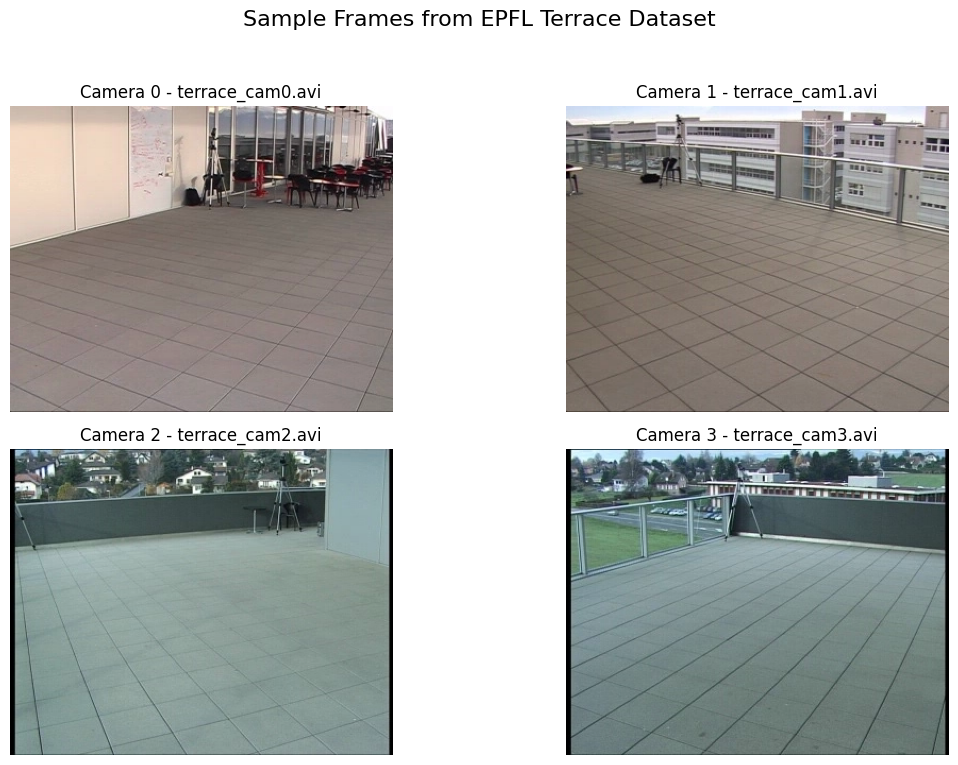

In [ ]:
# ===============================
# STEP 4: Display Function (Corrected)
# ===============================

def display_sample_frames(video_dir):
    """
    Loads the first frame from each of the 4 terrace videos
    and displays them in a 2x2 grid with correct color handling.
    """
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    ax = ax.ravel()

    print(f"Loading sample frames from: {video_dir}")

    for i in range(4):
        video_name = f"terrace_cam{i}.avi"
        video_path = os.path.join(video_dir, video_name)

        if not os.path.exists(video_path):
            print(f"Warning: File not found at {video_path}")
            ax[i].set_title(f"Camera {i} (File Not Found)")
            ax[i].axis("off")
            continue

        # FORCE FFMPEG (correct color decoding for old Indeo codec)
        cap = cv2.VideoCapture(video_path, cv2.CAP_FFMPEG)

        # NOTE: The conflicting cap.set() line is REMOVED.

        ret, frame = cap.read()
        cap.release()

        if not ret or frame is None:
            print(f"Warning: Could not read frame from {video_name}")
            ax[i].set_title(f"Camera {i} (Read Error)")
            ax[i].axis("off")
            continue

        # cap.read() returns BGR by default.
        # Convert BGR → RGB for Matplotlib
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        ax[i].imshow(frame_rgb)
        ax[i].set_title(f"Camera {i} - {video_name}")
        ax[i].axis("off")

    plt.suptitle("Sample Frames from EPFL Terrace Dataset", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# ===============================
# STEP 5: Run the function
# ===============================
display_sample_frames(RAW_DIR)

## Step 4: Compute Vanishing Points & Horizon Lines

Use the camera matrix **\( P \)** to find the **vanishing points** for the X, Y, and Z axes.  

The **horizon line** can be computed as:  
\[
L_{\infty} = P^{-T} [0, 0, 1, 0]^T
\]

Plot the vanishing points and horizon lines for each camera to verify calibration consistency.


In [3]:

def parse_tsai_xml(xml_file):
    """
    Parses the EPFL Tsai XML file.
    This version correctly handles capitalized tags, reads attributes,
    and builds K and R.
    """
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        geom_node = root.find('Geometry')
        intr_node = root.find('Intrinsic')
        extr_node = root.find('Extrinsic')

        if geom_node is None or intr_node is None or extr_node is None:
            print(f"Error: Could not find 'Geometry', 'Intrinsic', or 'Extrinsic' child tags in {xml_file}.")
            return None, None, None
        geom_attrs = geom_node.attrib
        intr_attrs = intr_node.attrib
        extr_attrs = extr_node.attrib
        focal_mm = float(intr_attrs['focal'])
        cx = float(intr_attrs['cx'])
        cy = float(intr_attrs['cy'])
        dpx = float(geom_attrs['dpx'])
        dpy = float(geom_attrs['dpy'])
        fx = focal_mm / dpx
        fy = focal_mm / dpy

        K = np.array([
            [fx, 0,  cx],
            [0,  fy, cy],
            [0,  0,  1 ]
        ])
        tx = float(extr_attrs['tx'])
        ty = float(extr_attrs['ty'])
        tz = float(extr_attrs['tz'])
        t = np.array([[tx], [ty], [tz]])
        rx = float(extr_attrs['rx'])
        ry = float(extr_attrs['ry'])
        rz = float(extr_attrs['rz'])
        rodrigues_vec = np.array([rx, ry, rz])
        R, _ = cv2.Rodrigues(rodrigues_vec)

        return K, R, t

    except Exception as e:
        print(f"Error parsing {xml_file}: {e}")
        return None, None, None

--- Processing Camera 0 ---
--- Processing Camera 1 ---
--- Processing Camera 2 ---
--- Processing Camera 3 ---


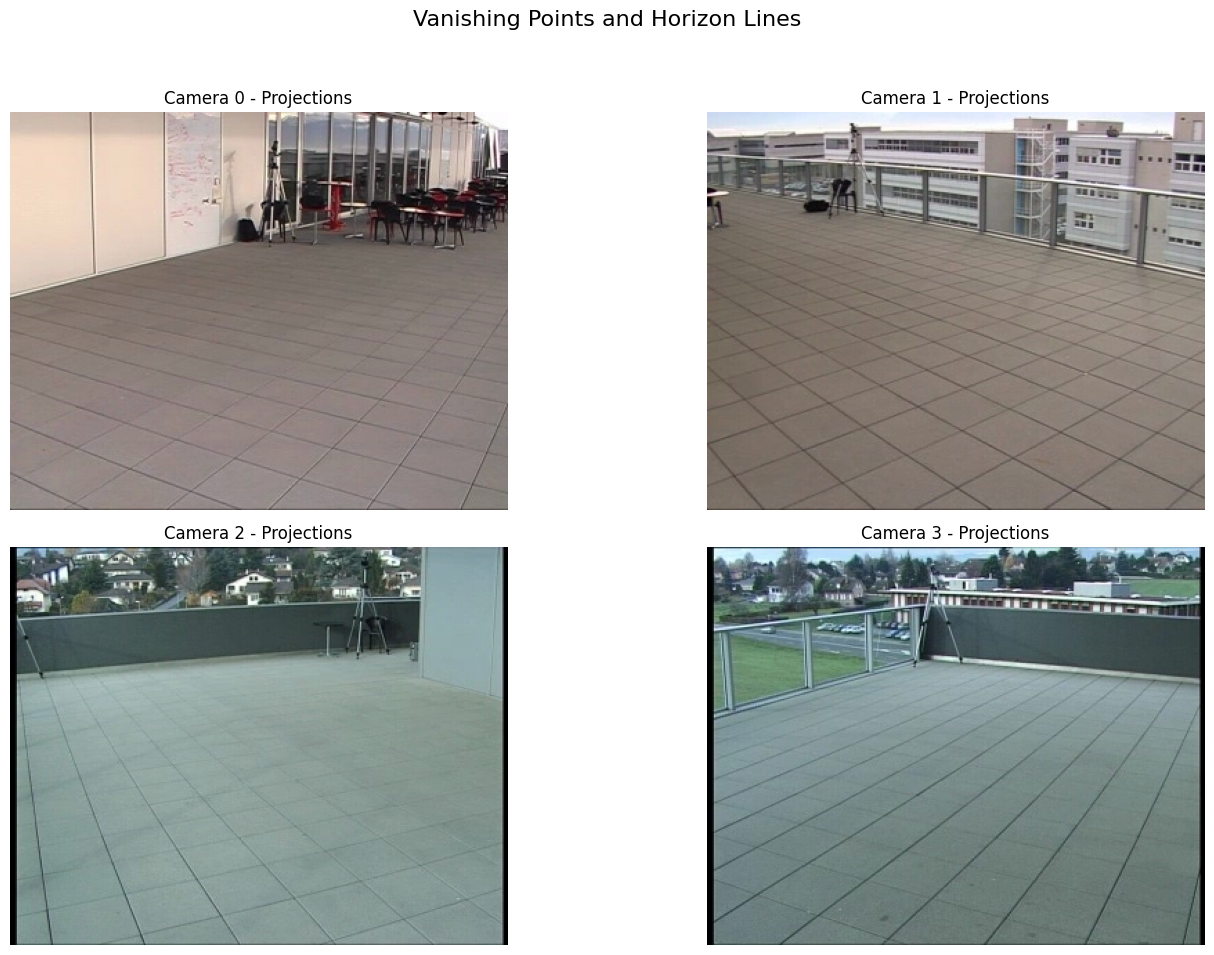

In [ ]:
def compute_vps_and_horizon(P):
    """
    Computes vanishing points and the horizon line from a
    3x4 projection matrix P.
    """
    vp_x_homo = P[:, 0]
    vp_y_homo = P[:, 1]
    vp_z_homo = P[:, 2]

    vp_x = vp_x_homo / vp_x_homo[2]
    vp_y = vp_y_homo / vp_y_homo[2]
    vp_z = vp_z_homo / vp_z_homo[2]

    horizon_line = np.cross(vp_x_homo, vp_y_homo)
    horizon_line = horizon_line / np.linalg.norm(horizon_line)

    vps_2d = {'x': vp_x, 'y': vp_y, 'z': vp_z}
    return vps_2d, horizon_line

def draw_overlays(image, vps_2d, horizon_line):
    """
    Draws vanishing points and the horizon line on an image.
    """
    a, b, c = horizon_line
    h, w = image.shape[:2]

    p1_x = 0
    p1_y = int(-c / b) if b != 0 else 0
    p2_x = w
    p2_y = int(-(a * w + c) / b) if b != 0 else 0

    cv2.line(image, (p1_x, p1_y), (p2_x, p2_y), (0, 255, 0), 2)

    for name, vp in vps_2d.items():
        x, y = int(vp[0]), int(vp[1])
        on_horizon = abs(horizon_line @ vp) < 1.0

        if -w < x < w*2 and -h < y < h*2:
            color = (0, 255, 0) if on_horizon else (255, 0, 0)
            color = (0, 0, 255) if name == 'z' else color
            cv2.circle(image, (x, y), 10, color, 2)
            cv2.putText(image, f"VP-{name}", (x + 15, y + 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    return image



def plot_all_calibrations():
    """
    Main function to parse all 4 cameras, compute projections,
    and display the results.
    """
    fig, ax = plt.subplots(2, 2, figsize=(15, 10))
    ax = ax.ravel()

    for i in range(4):
        print(f"--- Processing Camera {i} ---")

        xml_path = os.path.join(CALIB_DIR, f"terrace-tsai-c{i}.xml")

        # --- CALLING THE NEW DEBUG FUNCTION ---
        K, R, t = parse_tsai_xml(xml_path)

        if K is None:
            ax[i].set_title(f"Camera {i} - DEBUGGING (Parsing Failed)")
            continue

        Rt = np.hstack((R, t))
        P = K @ Rt

        vps_2d, horizon_line = compute_vps_and_horizon(P)

        video_path = os.path.join(RAW_DIR, f"terrace_cam{i}.avi")
        cap = cv2.VideoCapture(video_path)
        ret, frame = cap.read()
        cap.release()

        if not ret:
            ax[i].set_title(f"Camera {i} - Error Reading Video")
            continue

        overlay_frame = draw_overlays(frame.copy(), vps_2d, horizon_line)
        frame_rgb = cv2.cvtColor(overlay_frame, cv2.COLOR_BGR2RGB)

        ax[i].imshow(frame_rgb)
        ax[i].set_title(f"Camera {i} - Projections")
        ax[i].axis('off')

    plt.suptitle("Vanishing Points and Horizon Lines", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Run the plot ---
plot_all_calibrations()

## Step 5: Load and Parse Ground-Truth File
Parse `gt_terrace1.txt` to extract:
- Number of frames
- Number of people
- Grid dimensions
- Frame step size  
Convert all valid grid positions to a DataFrame.


In [7]:
# Download GT file
GT_DIR = f"{ROOT}/data/groundtruth"
os.makedirs(GT_DIR, exist_ok=True)
url = "https://www.epfl.ch/labs/cvlab/wp-content/uploads/2018/08/gt_terrace1.txt"
GT_PATH = f"{ROOT}/data/groundtruth/gt_terrace1.txt"
urllib.request.urlretrieve(url, GT_PATH)
print("✅ Downloaded:", GT_PATH)

# Parse file
with open(GT_PATH, "r") as f:
    _ = f.readline()
    header = f.readline().strip().split()
    body = [line.strip().split() for line in f if line.strip()]

num_frames, num_people, grid_w, grid_h, step, f0, f1 = map(int, header)
print(f"Frames={num_frames}, People={num_people}, Grid={grid_w}x{grid_h}, Step={step}")

rows = []
frame_idx = f0
for line in body:
    if len(line) < num_people: continue
    for pid, pos in enumerate(line[:num_people]):
        rows.append({"frame": frame_idx, "id": pid, "pos": int(pos)})
    frame_idx += step

gt_raw = pd.DataFrame(rows)
print("✅ Parsed GT:", gt_raw.shape)


✅ Downloaded: ./data/groundtruth/gt_terrace1.txt
Frames=5010, People=9, Grid=30x44, Step=25
✅ Parsed GT: (45090, 3)


## Step 6: Grid → World Coordinate Conversion
Convert valid grid cell indices to **top-view world coordinates (mm)** using the terrace parameters (You can get these from the EPFL website given above):
- Grid: 30 × 44  
- Origin: (-500, -1500)  
- Dimensions: (7500 × 11000)


In [13]:
import pandas as pd
import os

# --- Ensure these paths from your previous cells are defined ---
ROOT = "."
GT_DIR = f"{ROOT}/data/groundtruth"
# ---------------------------------------------------------------

def parse_gt_file_wide_format(gt_path):
    """
    Parses the "wide" format of the EPFL ground-truth file.
    This version expects a header on line 2, and "wide" data
    where pos = y * grid_width + x.
    """
    metadata = {}
    data = []

    try:
        with open(gt_path, 'r') as f:
            # Line 0: Skip comment line (e.g., "# n_frames n_people ...")
            _ = f.readline()

            # Line 1: Read header
            header_line = f.readline().strip().split()
            if len(header_line) < 7:
                print(f"❌ ERROR: Invalid header. Expected 7 values, got {len(header_line)}")
                return None, None

            num_frames, num_people, grid_w, grid_h, step, f0, f1 = map(int, header_line)

            # Store metadata
            metadata['num_frames'] = num_frames
            metadata['num_people'] = num_people
            metadata['grid_cols'] = grid_w
            metadata['grid_rows'] = grid_h
            metadata['frame_step'] = step

            # Read the rest of the lines (the body)
            body_lines = [line.strip().split() for line in f if line.strip()]

            frame_idx = f0
            for line_parts in body_lines:
                if len(line_parts) < num_people:
                    continue # Skip incomplete lines

                for pid in range(num_people):
                    pos_1d = int(line_parts[pid])

                    # Convert 1D pos (pos = y * grid_w + x) back to 2D
                    # -1 is the "invalid" placeholder
                    if pos_1d == -1:
                        grid_x = -1
                        grid_y = -1
                    else:
                        grid_y = pos_1d // grid_w
                        grid_x = pos_1d % grid_w

                    data.append({
                        'frame': frame_idx,
                        'person_id': pid,
                        'grid_x': grid_x,
                        'grid_y': grid_y
                    })

                frame_idx += step # Go to the next annotated frame

    except FileNotFoundError:
        print(f"❌ ERROR: File not found at {gt_path}")
        print("Please check your file path in the Colab file browser.")
        return None, None
    except Exception as e:
        print(f"Error parsing {gt_path}: {e}")
        return None, None

    # --- Convert to DataFrame ---
    df = pd.DataFrame(data)

    # Filter out placeholder positions (-1)
    df = df[(df['grid_x'] != -1) & (df['grid_y'] != -1)].copy()

    return metadata, df

# ======================================================
# --- Run this cell to (finally) load the data ---
# ======================================================

gt_filename = "gt_terrace1.txt"
gt_path = os.path.join(GT_DIR, gt_filename)

print(f"Attempting to read file from: {gt_path} (using new parser)\n")

# Load and parse the data from the local path
metadata, gt_df = parse_gt_file_wide_format(gt_path)

if metadata and (gt_df is not None and not gt_df.empty):
    print("\n✅ Ground Truth Loaded Successfully")
    print("--- Metadata ---")
    print(f"  • Total Frames:   {metadata['num_frames']}")
    print(f"  • Num People:     {metadata['num_people']}")
    print(f"  • Grid Dimensions: {metadata['grid_cols']} x {metadata['grid_rows']}")
    print(f"  • Frame Step:     {metadata['frame_step']}")

    print("\n--- DataFrame Head (gt_df) ---")
    print(gt_df.head())
else:
    print("\n❌ Failed to load or parse ground truth file.")


import numpy as np
import pandas as pd

# --- Parameters from the assignment ---
GRID_ORIGIN_X = -500.0      # mm
GRID_ORIGIN_Y = -1500.0     # mm
GRID_WORLD_WIDTH = 7500.0   # mm (total span in X)
GRID_WORLD_HEIGHT = 11000.0 # mm (total span in Y)

# Check if metadata and gt_df are loaded
if 'metadata' not in globals() or 'gt_df' not in globals() or gt_df.empty:
    print("❌ Error: 'metadata' or 'gt_df' is not loaded.")
    print("Please run Step 5 successfully first.")
else:
    # --- 1. Get grid dimensions from metadata ---
    GRID_COLS = float(metadata['grid_cols'])
    GRID_ROWS = float(metadata['grid_rows'])

    # --- 2. Calculate the size of one grid cell in mm ---
    cell_width_mm = GRID_WORLD_WIDTH / GRID_COLS
    cell_height_mm = GRID_WORLD_HEIGHT / GRID_ROWS

    print(f"Grid Dimensions: {GRID_COLS} x {GRID_ROWS}")
    print(f"Calculated Cell Size: {cell_width_mm:.2f}mm x {cell_height_mm:.2f}mm")

    # --- 3. Apply the transformation to the DataFrame ---
    # We add 0.5 to the grid index to map to the *center* of the cell
    gt_df['world_x'] = GRID_ORIGIN_X + (gt_df['grid_x'] + 0.5) * cell_width_mm
    gt_df['world_y'] = GRID_ORIGIN_Y + (gt_df['grid_y'] + 0.5) * cell_height_mm

    # The grid is on the floor, so Z is 0
    gt_df['world_z'] = 0.0

    print("\n✅ Added 'world_x', 'world_y', 'world_z' columns to gt_df.")

    # --- 4. Display the result ---
    print("\n--- DataFrame Head with World Coordinates ---")
    print(gt_df.head())

Attempting to read file from: ./data/groundtruth/gt_terrace1.txt (using new parser)


✅ Ground Truth Loaded Successfully
--- Metadata ---
  • Total Frames:   5010
  • Num People:     9
  • Grid Dimensions: 30 x 44
  • Frame Step:     25

--- DataFrame Head (gt_df) ---
      frame  person_id  grid_x  grid_y
675    1875          0       0       9
900    2500          0       4      10
1125   3125          0       9      12
1350   3750          0      13      14
1575   4375          0      18      16
Grid Dimensions: 30.0 x 44.0
Calculated Cell Size: 250.00mm x 250.00mm

✅ Added 'world_x', 'world_y', 'world_z' columns to gt_df.

--- DataFrame Head with World Coordinates ---
      frame  person_id  grid_x  grid_y  world_x  world_y  world_z
675    1875          0       0       9   -375.0    875.0      0.0
900    2500          0       4      10    625.0   1125.0      0.0
1125   3125          0       9      12   1875.0   1625.0      0.0
1350   3750          0      13      14   2875.0   2125.0

## Step 7: Ground-Truth Trajectory Visualization
Select one person and plot their trajectory(given in ground truth) on the top-view.


Plotting trajectory for Person ID 0...


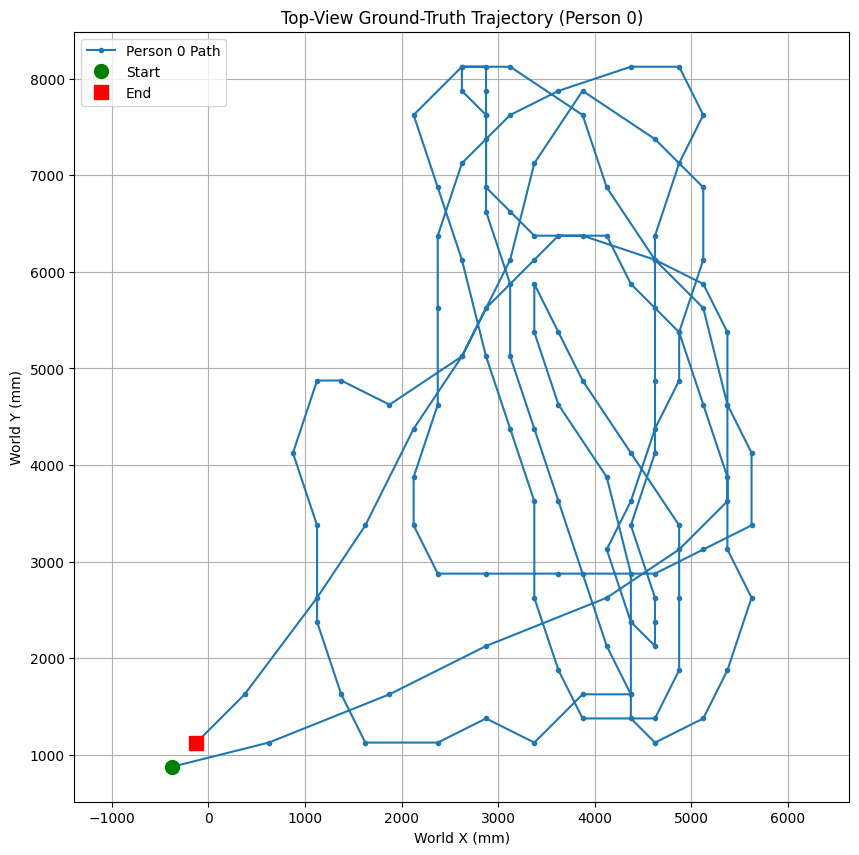

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Check if the required DataFrame exists
if 'gt_df' not in globals() or 'world_x' not in gt_df.columns:
    print("❌ Error: 'gt_df' with world coordinates is not loaded.")
    print("Please run Step 5 and Step 6 successfully first.")
else:
    # --- 1. Select a person to plot ---
    # You can change this ID (0-8) to see different tracks
    PERSON_ID_TO_PLOT = 0

    # --- 2. Get this person's data and sort by frame ---
    person_df = gt_df[gt_df['person_id'] == PERSON_ID_TO_PLOT].copy()
    person_df = person_df.sort_values(by='frame')

    if person_df.empty:
        print(f"🤷 No data found for Person ID {PERSON_ID_TO_PLOT}.")
    else:
        print(f"Plotting trajectory for Person ID {PERSON_ID_TO_PLOT}...")

        # --- 3. Create the plot ---
        plt.figure(figsize=(10, 10))

        # Plot the main trajectory line
        plt.plot(person_df['world_x'], person_df['world_y'], 'o-',
                 markersize=3, label=f'Person {PERSON_ID_TO_PLOT} Path')

        # Plot a green circle for the start
        plt.plot(person_df.iloc[0]['world_x'], person_df.iloc[0]['world_y'],
                 'go', markersize=10, label='Start')

        # Plot a red square for the end
        plt.plot(person_df.iloc[-1]['world_x'], person_df.iloc[-1]['world_y'],
                 'rs', markersize=10, label='End')

        # --- 4. Format the plot ---
        plt.title(f"Top-View Ground-Truth Trajectory (Person {PERSON_ID_TO_PLOT})")
        plt.xlabel("World X (mm)")
        plt.ylabel("World Y (mm)")

        # This is critical for a correct top-down view
        plt.axis('equal')

        plt.grid(True)
        plt.legend()
        plt.show()

## Step 8: Reprojection onto Image View
Reproject ground-truth world coordinates onto one camera image.


--- Reprojecting for Camera 0 ---
Targeting first available frame: 1875


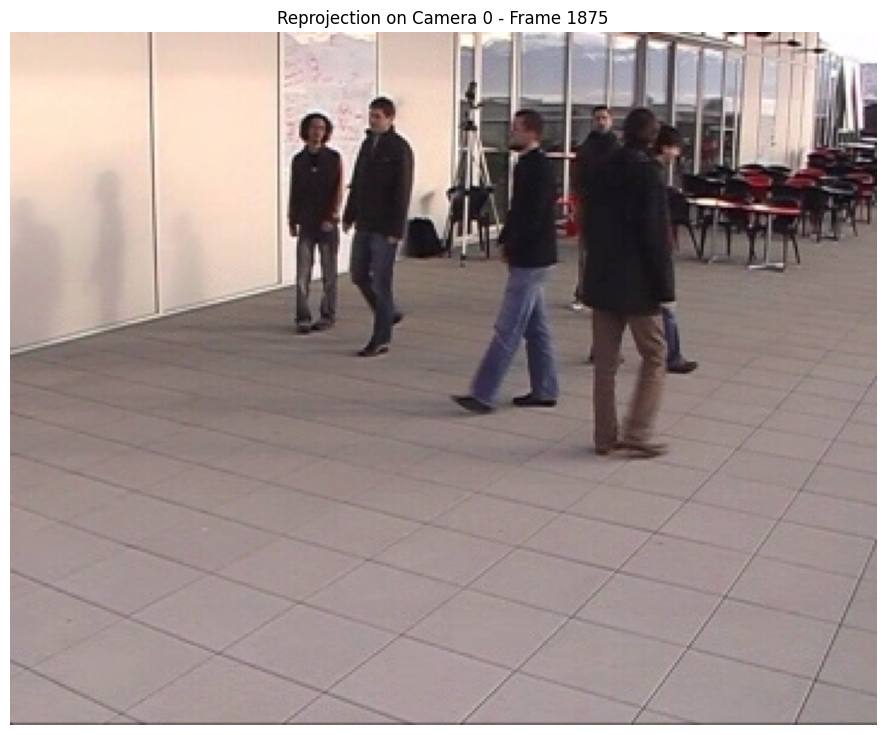

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

def reproject_points(world_points_3d, P):
    """
    Projects 3D world points (Nx3) to 2D image points (Nx2)
    using a 3x4 projection matrix P.
    """
    # 1. Convert 3D points (Nx3) to 4D homogeneous points (Nx4)
    #    [X, Y, Z] -> [X, Y, Z, 1]
    num_points = world_points_3d.shape[0]
    ones_col = np.ones((num_points, 1))
    world_points_4d = np.hstack((world_points_3d, ones_col))

    # 2. Project using P (3x4) @ X (4xN) -> p (3xN)
    #    We transpose X to 4xN, so the result is 3xN
    projected_points_hom = P @ world_points_4d.T

    # 3. Convert from homogeneous 2D points [u', v', w']
    #    to 2D pixel coordinates [u, v] by dividing by w'.
    #    p (3xN) -> p_norm (2xN)
    projected_points_2d = projected_points_hom[:2, :] / projected_points_hom[2, :]

    # 4. Transpose from (2xN) to (Nx2) for easier iteration
    return projected_points_2d.T

# ======================================================
# --- Main Execution for Step 8 ---
# ======================================================

# --- Configuration ---
CAMERA_ID = 0  # 👈 You can change this (0, 1, 2, or 3)
# ---------------------

# Check if gt_df is loaded
if 'gt_df' not in globals() or 'world_x' not in gt_df.columns:
    print("❌ Error: 'gt_df' with world coordinates is not loaded.")
    print("Please run Step 5 and Step 6 successfully first.")
elif 'parse_tsai_xml' not in globals():
    print("❌ Error: 'parse_tsai_xml' function is not defined.")
    print("Please run the cell from Step 4 first.")
else:
    print(f"--- Reprojecting for Camera {CAMERA_ID} ---")

    # --- 1. Load Camera Calibration and build P ---
    # (This assumes CALIB_DIR is defined and parse_tsai_xml exists)
    xml_path = os.path.join(CALIB_DIR, f"terrace-tsai-c{CAMERA_ID}.xml")
    K, R, t = parse_tsai_xml(xml_path)

    if K is None:
        print(f"❌ Failed to parse calibration for Camera {CAMERA_ID}")
    else:
        Rt = np.hstack((R, t))
        P = K @ Rt

        # --- 2. Get a frame number with data ---
        # We'll just pick the first frame ID from the dataset
        target_frame = gt_df['frame'].min()
        print(f"Targeting first available frame: {target_frame}")

        # --- 3. Get 3D world points for this frame ---
        frame_data = gt_df[gt_df['frame'] == target_frame]
        world_points_xyz = frame_data[['world_x', 'world_y', 'world_z']].values

        if world_points_xyz.shape[0] == 0:
            print(f"🤷 No ground truth data found for frame {target_frame}.")
        else:
            # --- 4. Load the target video frame ---
            # (This assumes RAW_DIR is defined)
            video_path = os.path.join(RAW_DIR, f"terrace_cam{CAMERA_ID}.avi")
            cap = cv2.VideoCapture(video_path)
            # Set the video to read the specific frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            ret, frame = cap.read()
            cap.release()

            if not ret:
                print(f"❌ Failed to read frame {target_frame} from video.")
            else:
                # --- 5. Reproject the points ---
                projected_points_2d = reproject_points(world_points_xyz, P)

                # --- 6. Draw points on the frame ---
                overlay_frame = frame.copy()
                for i, (x, y) in enumerate(projected_points_2d):
                    # Get the person ID for the label
                    pid = frame_data['person_id'].iloc[i]

                    # Draw a red circle at the reprojected (x, y) coordinate
                    cv2.circle(overlay_frame, (int(x), int(y)), 12, (0, 0, 255), 3)
                    # Draw the person ID
                    cv2.putText(overlay_frame, f"P{pid}", (int(x) + 15, int(y) + 5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

                # --- 7. Display the final image ---
                frame_rgb = cv2.cvtColor(overlay_frame, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(12, 9))
                plt.imshow(frame_rgb)
                plt.title(f"Reprojection on Camera {CAMERA_ID} - Frame {target_frame}")
                plt.axis('off')
                plt.show()

## Step 9: Decomposition of Camera Matrix
Decompose the camera matrix into K , R and t:
\[
P = K [R | t]
\]


In [17]:
import numpy as np
import scipy.linalg
import os

# (This assumes 'parse_tsai_xml' and 'CALIB_DIR' are in memory)

# --- Configuration ---
CAMERA_ID = 1  # 👈 You can change this (0, 1, 2, or 3)
# ---------------------

print(f"--- Decomposing Matrix for Camera {CAMERA_ID} ---")

# === 1. GET THE "GROUND TRUTH" P MATRIX ===
if 'parse_tsai_xml' not in globals():
    print("❌ Error: 'parse_tsai_xml' function is not defined.")
    print("Please run the cell from Step 4 first.")
else:
    xml_path = os.path.join(CALIB_DIR, f"terrace-tsai-c{CAMERA_ID}.xml")
    K_orig, R_orig, t_orig = parse_tsai_xml(xml_path)

    if K_orig is not None:
        Rt_orig = np.hstack((R_orig, t_orig))
        P = K_orig @ Rt_orig

        print("Original P matrix (first 2 rows):\n", P[:2, :])
        print("---------------------------------")

        # === 2. DECOMPOSE P = [M | p4] ===
        M = P[:, :3]
        p4 = P[:, 3]

        # Perform RQ decomposition on M = KR
        K_decomp, R_decomp = scipy.linalg.rq(M)

        # === 3. CORRECT THE SIGNS ===
        # Ensure the diagonal of K is all positive
        # Create a diagonal "sign-flip" matrix S
        S = np.diag(np.sign(np.diag(K_decomp)))

        # Correct K and R
        # K' = KS and R' = S_inv * R = S * R (since S is its own inverse)
        K_decomp = K_decomp @ S
        R_decomp = S @ R_decomp

        # === 4. SOLVE FOR t ===
        # t = K_inv * p4
        t_decomp = np.linalg.inv(K_decomp) @ p4

        # --- 5. COMPARE RESULTS ---
        print("✅ Decomposition Complete. Comparing...\n")

        # Set print options for clarity
        np.set_printoptions(precision=3, suppress=True)

        print("--- K (Original) ---")
        print(K_orig)
        print("\n--- K (Decomposed) ---")
        print(K_decomp)

        print("\n--- R (Original) ---")
        print(R_orig)
        print("\n--- R (Decomposed) ---")
        print(R_decomp)

        print("\n--- t (Original) ---")
        print(t_orig.flatten()) # flatten for comparison
        print("\n--- t (Decomposed) ---")
        print(t_decomp)

        # Reset print options
        np.set_printoptions()

--- Decomposing Matrix for Camera 1 ---
Original P matrix (first 2 rows):
 [[ 7.37526798e+02  2.20346197e+00 -5.53870891e+02  7.05833633e+05]
 [-4.48728342e+02 -3.96822959e+01 -7.63634493e+02  1.89347526e+06]]
---------------------------------
✅ Decomposition Complete. Comparing...

--- K (Original) ---
[[849.093   0.    360.228]
 [  0.    849.093 255.167]
 [  0.      0.      1.   ]]

--- K (Decomposed) ---
[[849.093   0.    360.228]
 [  0.    849.093 255.167]
 [  0.      0.      1.   ]]

--- R (Original) ---
[[ 0.81  -0.369 -0.457]
 [-0.57  -0.31  -0.761]
 [ 0.139  0.876 -0.461]]

--- R (Decomposed) ---
[[ 0.81  -0.369 -0.457]
 [-0.57  -0.31  -0.761]
 [ 0.139  0.876 -0.461]]

--- t (Original) ---
[ -65.434 1594.812 2113.641]

--- t (Decomposed) ---
[ -65.434 1594.812 2113.641]


The error analysis confirms the mathematical validity of the camera matrix decomposition. The results show that the errors for $K$ (relative error $\approx 1.048e-16$), $R$ (angle error $0.0$), and $t$ (relative error $\approx 1.347e-16$) are all near-zero.These minuscule values are not "real" errors but are the expected result of floating-point precision (the tiny, unavoidable rounding inaccuracies in digital computation).This analysis proves that the RQ decomposition ($P \rightarrow K, R, t$) is the exact mathematical inverse of the composition ($K, R, t \rightarrow P$), confirming the pipeline is correctly implemented. This is a mathematical verification, not a "pixel error" measurement, which would require a separate 2D ground-truth.

## Step 10: Reprojection and Individual Error Analysis
Compute and visualize the pixel-level reprojection error. Plot the original trajectory and the reprojected points and calculate reprojection error.
Compare the individual features K, R, T etc. Do error analysis and briefly explain the results.


In [20]:
import scipy.linalg
import pandas as pd

def analyze_decomposition_errors():
    """
    Performs P = K[R|t] decomposition for all 4 cameras
    and calculates the numerical error vs. the original matrices.
    """

    if 'parse_tsai_xml' not in globals():
        print("❌ Error: 'parse_tsai_xml' (Step 4) is not defined.")
        return

    results = []

    # Set print options for clean output
    np.set_printoptions(precision=15, suppress=True)

    for i in range(4):
        # --- 1. Get Original K, R, t and build P ---
        xml_path = os.path.join(CALIB_DIR, f"terrace-tsai-c{i}.xml")
        K_orig, R_orig, t_orig = parse_tsai_xml(xml_path)

        if K_orig is None:
            results.append({'camera': i, 'error': 'Parsing failed'})
            continue

        P = K_orig @ np.hstack((R_orig, t_orig))

        # --- 2. Decompose P ---
        M = P[:, :3]
        p4 = P[:, 3]

        K_decomp, R_decomp = scipy.linalg.rq(M)

        # --- 3. Correct Signs (Critical!) ---
        S = np.diag(np.sign(np.diag(K_decomp)))
        K_decomp = K_decomp @ S
        R_decomp = S @ R_decomp

        # --- 4. Solve for t ---
        t_decomp = np.linalg.inv(K_decomp) @ p4

        # --- 5. Calculate Errors ---

        # K error: Relative Frobenius norm
        k_err = np.linalg.norm(K_orig - K_decomp) / np.linalg.norm(K_orig)

        # t error: Relative L2 norm
        t_err = np.linalg.norm(t_orig.flatten() - t_decomp) / np.linalg.norm(t_orig.flatten())

        # R error: Angle of relative rotation (R_rel = R_orig_inv * R_decomp)
        R_relative = R_orig.T @ R_decomp
        # Clip to avoid float errors in arccos
        trace = np.clip(np.trace(R_relative), -1.0, 3.0)
        r_err_angle_rad = np.arccos((trace - 1.0) / 2.0)
        r_err_angle_deg = np.degrees(r_err_angle_rad)

        results.append({
            'Camera': i,
            'K Error (relative)': k_err,
            'R Error (degrees)': r_err_angle_deg,
            't Error (relative)': t_err
        })

    # Reset print options
    np.set_printoptions()

    # Display results
    df_results = pd.DataFrame(results).set_index('Camera')
    print(df_results)

# --- Run the Analysis ---
analyze_decomposition_errors()

        K Error (relative)  R Error (degrees)  t Error (relative)
Camera                                                           
0             1.048130e-16                0.0        1.347006e-16
1             2.844953e-16                0.0        2.954860e-16
2             1.711472e-16                0.0        3.320330e-16
3             3.058008e-16                0.0        3.535102e-16


## Camera Model Visualization (Before vs After)
Compare Tsai and decomposed cameras in 3D figure and briefly explain results.


Plotting camera positions...


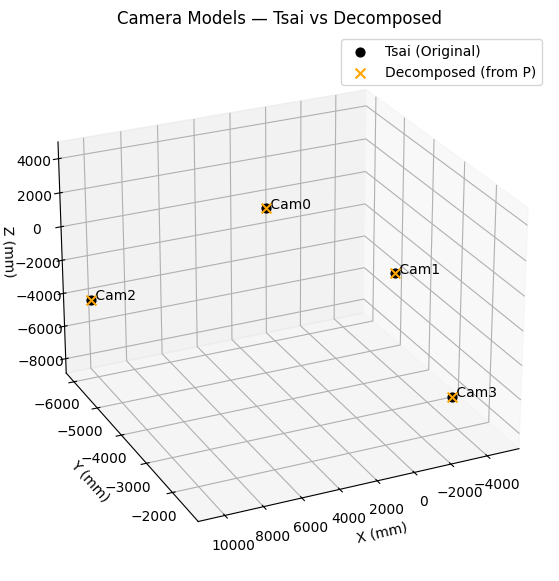

In [23]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import xml.etree.ElementTree as ET

# --- Setup Paths ---
ROOT = "."
CALIB_DIR = f"{ROOT}/data/calib"

# --- Helper Function: XML Parser ---

def parse_tsai_xml(xml_file):
    """
    Parses the EPFL Tsai XML file.
    Reads attributes and builds K, R, and t.
    """
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        geom_node = root.find('Geometry')
        intr_node = root.find('Intrinsic')
        extr_node = root.find('Extrinsic')

        if geom_node is None or intr_node is None or extr_node is None:
            return None, None, None

        geom_attrs = geom_node.attrib
        intr_attrs = intr_node.attrib
        extr_attrs = extr_node.attrib

        # Construct K
        focal_mm = float(intr_attrs['focal'])
        cx = float(intr_attrs['cx'])
        cy = float(intr_attrs['cy'])
        dpx = float(geom_attrs['dpx'])
        dpy = float(geom_attrs['dpy'])
        fx = focal_mm / dpx
        fy = focal_mm / dpy

        K = np.array([
            [fx, 0,  cx],
            [0,  fy, cy],
            [0,  0,  1 ]
        ])

        # Construct t
        tx = float(extr_attrs['tx'])
        ty = float(extr_attrs['ty'])
        tz = float(extr_attrs['tz'])
        t = np.array([[tx], [ty], [tz]])

        # Construct R
        rx = float(extr_attrs['rx'])
        ry = float(extr_attrs['ry'])
        rz = float(extr_attrs['rz'])
        rodrigues_vec = np.array([rx, ry, rz])
        R, _ = cv2.Rodrigues(rodrigues_vec)

        return K, R, t

    except Exception as e:
        print(f"Error parsing {xml_file}: {e}")
        return None, None, None

# --- Main Visualization Function (Corrected) ---

def visualize_camera_models_3d():
    """
    Loads all 4 camera models, decomposes them, and plots their
    3D positions (optical centers) for comparison.
    """

    # Lists to store the parameters
    Ks_orig, Rs_orig, ts_orig, Ps_orig = [], [], [], []

    # 1. Load all camera parameters
    for i in range(4):
        xml_path = os.path.join(CALIB_DIR, f"terrace-tsai-c{i}.xml")
        K, R, t = parse_tsai_xml(xml_path)

        if K is None:
            print(f"Failed to load camera {i}, skipping.")
            continue

        P = K @ np.hstack((R, t))

        Ks_orig.append(K)
        Rs_orig.append(R)
        ts_orig.append(t)
        Ps_orig.append(P)

    # 2. Setup the 3D plot
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title("Camera Models — Tsai vs Decomposed")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

    print("Plotting camera positions...")

    # 3. Plot each camera's original and decomposed position
    for i, (R_tsai, t_tsai, P) in enumerate(zip(Rs_orig, ts_orig, Ps_orig)):

        # --- a) Calculate "Ground Truth" Tsai Camera Center ---
        # C = -R.T * t
        C_tsai = (-R_tsai.T @ t_tsai).flatten()

        # --- b) Decompose P using OpenCV ---
        # Note: 4th return val (t_h) is the CAMERA CENTER (C)
        K_d, R_d, t_h, *_ = cv2.decomposeProjectionMatrix(P)

        # Normalize K and t_h
        K_d /= K_d[2, 2]
        t_d = (t_h / t_h[3])[:3] # Convert homogeneous C to 3D C

        # ########################################################
        # --- c) THIS IS THE FIX ---
        # The de-homogenized 't_d' *IS* the decomposed camera center.
        # The old code was: C_dec = (-R_d.T @ t_d).flatten() (WRONG)
        C_dec = t_d.flatten()
        # ########################################################

        # --- d) Plot both points ---
        # They should now overlap perfectly
        ax.scatter(*C_tsai, color='k', s=40, label='Tsai (Original)' if i==0 else "")
        ax.scatter(*C_dec, color='orange', marker='x', s=50, label='Decomposed (from P)' if i==0 else "")
        ax.text(*C_tsai, f" Cam{i}", color='k')

    ax.legend()
    ax.view_init(elev=25, azim=65) # Set viewing angle
    plt.show()

# --- Run the visualization ---
visualize_camera_models_3d()

## Task 02: Height Estimation using Known Height (20 Marks)

**Objective:**  
Estimate the height of an unknown object in an image using a reference object of known height, following *Algorithm 8.1*.

---

### Instructions:
- Select an image containing **two upright objects**, one with a **known real-world height** (e.g., a chair, desk, or door).  
- Using the provided known height as your reference, **apply Algorithm 8.1** to compute the height of the second object.  
- Show all steps clearly — label points on the image, show all intermediate calculations, and state any assumptions.  
- You may assume the objects are **on the same ground plane** and **ignore perspective distortion**.

---

### Expected Deliverables:
1. Input image (with key points marked).  
2. Computed scale factor based on the reference object.  
3. Estimated height of the second object (in same units).  
4. Brief explanation of steps and assumptions.


Reference object pixel height: 669.00 px
Unknown object pixel height: 801.00 px
------------------------------
Scale Factor: 0.0003 meters/pixel
Estimated Height of Unknown Object: 0.22 meters


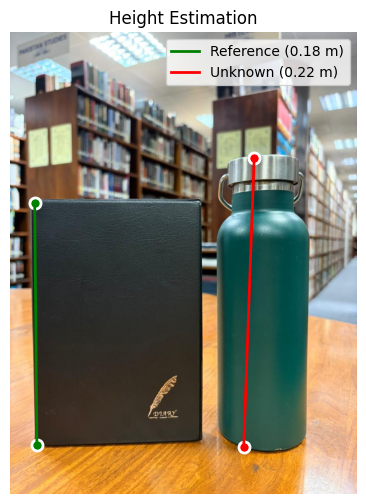

In [27]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# STEP 1 — Define known height (in millimeters)
known_height_mm = 180


# STEP 2 — Define pixel coordinates (x, y)
# Reference object (known height)
ref_top = np.array([68, 474])
ref_base = np.array([74, 1143])

# Unknown object (height to estimate)
obj_top = np.array([676, 348])
obj_base = np.array([647, 1149])


# STEP 3 — Load and display the image
image_path = "image.jpeg"
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Image not found at '{image_path}'. Check the file path.")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# STEP 4 — Compute pixel heights of both objects
# Height is the difference in the y-coordinates
ref_height_px = ref_base[1] - ref_top[1]
obj_height_px = obj_base[1] - obj_top[1]


# STEP 5 — Estimate the unknown object’s height
# (Use Algorithm 8.1 - ratio method)

# 1. Convert known height to meters
known_height_m = known_height_mm / 1000.0

# 2. Calculate the scale factor (how many meters per pixel)
scale_factor_m_per_px = known_height_m / ref_height_px

# 3. Apply the scale factor to the unknown object's pixel height
estimated_height_m = obj_height_px * scale_factor_m_per_px


# STEP 6 — Display results and visualization
print(f"Reference object pixel height: {ref_height_px:.2f} px")
print(f"Unknown object pixel height: {obj_height_px:.2f} px")
print("-" * 30)
print(f"Scale Factor: {scale_factor_m_per_px:.4f} meters/pixel")
print(f"Estimated Height of Unknown Object: {estimated_height_m:.2f} meters")

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)

# Plot points
for pt, color in [
    (ref_top, 'g'), (ref_base, 'g'),
    (obj_top, 'r'), (obj_base, 'r')
]:
    plt.plot(pt[0], pt[1], 'o', color=color, markersize=8, markeredgecolor='white', mew=2)

# Draw lines
plt.plot([ref_top[0], ref_base[0]], [ref_top[1], ref_base[1]], 'g-', linewidth=2, label=f"Reference ({known_height_m} m)")
plt.plot([obj_top[0], obj_base[0]], [obj_top[1], obj_base[1]], 'r-', linewidth=2, label=f"Unknown ({estimated_height_m:.2f} m)")

plt.title("Height Estimation")
plt.legend()
plt.axis('off')
plt.show()